Import des données

In [2]:
import pandas as pd
df = pd.read_csv(
'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)

df.head(2)

/tmp/ipykernel_8171/531837865.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2


Imports utiles pour le DM

In [3]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 72.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 75.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [great_tables] [great_tables]


In [4]:
import great_tables as gt
from great_tables import GT, style, loc


### Question 1 


On doit mettre à jour la variable code_commune en utilisant la variable actuelle et la variable code_departement. Pour cela, on va devoir concaténer les deux variables de telle sorte à obtenir ensuite un code à 5 chiffres. Les deux premiers chiffres correspondront au département (par exemple : 01 pour l'Ain, 59 pour le Nord) et les trois derniers au code commune (par exemple : 049 pour le code commune 49 dans le cas de Montrouge).

In [5]:
df['code_commune'] = df['code_commune'].astype(str).str.zfill(3)

df['code_commune'] = df['code_departement'].astype(str) + df['code_commune']

df.head(20)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0
5,01,Ain,01007,Ambronay,Nathalie,ARTHAUD,10
6,01,Ain,01008,Ambutrix,Nathalie,ARTHAUD,2
7,01,Ain,01009,Andert-et-Condon,Nathalie,ARTHAUD,1
8,01,Ain,01010,Anglefort,Nathalie,ARTHAUD,5
9,01,Ain,01011,Apremont,Nathalie,ARTHAUD,0


Nous devons également créer une colonne candidat qui comporte les prénoms et les noms de tous les candidats. Pour cela, nous allons concaténer les colonnes prenom et nom.

In [6]:
df["candidat"] = df["prenom"].astype(str) + " " + df["nom"].astype(str)

print(df['candidat'].unique())

['Nathalie ARTHAUD' 'Fabien ROUSSEL' 'Emmanuel MACRON' 'Jean LASSALLE'
 'Marine LE PEN' 'Éric ZEMMOUR' 'Jean-Luc MÉLENCHON' 'Anne HIDALGO'
 'Yannick JADOT' 'Valérie PÉCRESSE' 'Philippe POUTOU'
 'Nicolas DUPONT-AIGNAN' 'nan abstentions' 'nan blancs' 'nan nuls']


### Question 2

On souhaite déterminer le nombre de candidats qu'il y avait aux élections présidentielles de 2022. Pour cela, on va compter le nombre de candidats différents en excluant les votes blancs, les votes nuls et l'abstention.

In [7]:
candidats = len(df[~df.isin(['nan abstentions', 'nan blancs', 'nan nuls'])]['candidat'].unique())

f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."

"En 2022, il y avait 13 candidats à l'élection présidentielle."

### Question 3


In [8]:
exclus = ['nan abstentions', 'nan blancs', 'nan nuls']
df_exprimes = df[~df['candidat'].isin(exclus)]

scores = (
    df_exprimes
    .groupby('candidat', as_index=False)['voix']
    .sum()
    .sort_values('voix', ascending=False)
)

total_exprimes = scores['voix'].sum()
scores['pourcentage'] = (scores['voix'] / total_exprimes * 100).round(2)

(
    GT(scores)
    .tab_header(title="Résultats du 1er tour - Présidentielle 2022")
    .cols_label(candidat="Candidat", voix="Voix", pourcentage="% votes exprimés")
    .fmt_number(columns="voix", sep_mark=" ", dec_mark=",", decimals=0)
    .fmt_number(columns="pourcentage", decimals=2, dec_mark=",")
    .cols_align(align="right", columns=["voix", "pourcentage"])
)

GT(_tbl_data=                 candidat     voix  pourcentage
1         Emmanuel MACRON  9783058        27.85
5           Marine LE PEN  8133828        23.15
4      Jean-Luc MÉLENCHON  7712520        21.95
11           Éric ZEMMOUR  2485226         7.07
9        Valérie PÉCRESSE  1679001         4.78
10          Yannick JADOT  1627853         4.63
3           Jean LASSALLE  1101387         3.13
2          Fabien ROUSSEL   802422         2.28
7   Nicolas DUPONT-AIGNAN   725176         2.06
0            Anne HIDALGO   616478         1.75
8         Philippe POUTOU   268904         0.77
6        Nathalie ARTHAUD   197094         0.56, _body=<great_tables._gt_data.Body object at 0x7fd88ee9ba10>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='voix', type=<ColInfoTypeEnum.default: 1>, column_label='Voix', column_align='right', column_width=None), ColInfo(var='pourcentage', type=<ColInfoTypeEnum.default: 1>, column_label='% votes exprimés', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fd88ee9b4d0>, _spanners=Spanners([]), _heading=Heading(title='Résultats du 1er tour - Présidentielle 2022', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fd88ee9be00>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fd88eb82990>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fd7fd958050>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fd88ee9bcb0>, <great_tables._gt_data.FormatInfo object at 0x7fd88eb82ad0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_botto

# 2. Comparaison des scores départements aux moyennes nationales.

### Question 4 

In [9]:
total_dep = df_exprimes.groupby('code_departement')['voix'].sum().rename('total_dep')


score_departements = (
    df_exprimes
    .groupby(['code_departement', 'libelle_departement', 'candidat'], as_index=False)['voix']
    .sum()
)

score_departements = score_departements.merge(total_dep, on='code_departement')
score_departements['pourcentage'] = (score_departements['voix'] / score_departements['total_dep'] * 100).round(2)
score_departements = score_departements.drop(columns='total_dep')

score_departements.head(10).sort_values('pourcentage', ascending=False)

,code_departement,libelle_departement,candidat,voix,pourcentage
1,01,Ain,Emmanuel MACRON,92206,27.69
5,01,Ain,Marine LE PEN,86755,26.05
4,01,Ain,Jean-Luc MÉLENCHON,57832,17.37
9,01,Ain,Valérie PÉCRESSE,17572,5.28
3,01,Ain,Jean LASSALLE,10876,3.27
7,01,Ain,Nicolas DUPONT-AIGNAN,8998,2.70
2,01,Ain,Fabien ROUSSEL,5938,1.78
0,01,Ain,Anne HIDALGO,5644,1.69
8,01,Ain,Philippe POUTOU,2172,0.65
6,01,Ain,Nathalie ARTHAUD,1658,0.50


In [10]:
score_departements[score_departements['code_departement'] == '11'].sort_values('pourcentage', ascending=False)

,code_departement,libelle_departement,candidat,voix,pourcentage
125,11,Aude,Marine LE PEN,64027,30.14
121,11,Aude,Emmanuel MACRON,43104,20.29
124,11,Aude,Jean-Luc MÉLENCHON,42039,19.79
131,11,Aude,Éric ZEMMOUR,18434,8.68
123,11,Aude,Jean LASSALLE,12382,5.83
129,11,Aude,Valérie PÉCRESSE,7350,3.46
130,11,Aude,Yannick JADOT,6322,2.98
120,11,Aude,Anne HIDALGO,6166,2.90
122,11,Aude,Fabien ROUSSEL,5622,2.65
127,11,Aude,Nicolas DUPONT-AIGNAN,4206,1.98


### Question 5

In [11]:
score_departements = score_departements.rename(columns={'voix': 'voix_departement', 'pourcentage': 'score_departement'})
scores = scores.rename(columns={'voix' : 'voix_national', 'pourcentage':'score_national'})
question5 = pd.merge(
    score_departements, scores, left_on="candidat", right_on="candidat", how="left", sort=False
)


question5.head(10)

,code_departement,libelle_departement,candidat,voix_departement,score_departement,voix_national,score_national
0,01,Ain,Anne HIDALGO,5644,1.69,616478,1.75
1,01,Ain,Emmanuel MACRON,92206,27.69,9783058,27.85
2,01,Ain,Fabien ROUSSEL,5938,1.78,802422,2.28
3,01,Ain,Jean LASSALLE,10876,3.27,1101387,3.13
4,01,Ain,Jean-Luc MÉLENCHON,57832,17.37,7712520,21.95
5,01,Ain,Marine LE PEN,86755,26.05,8133828,23.15
6,01,Ain,Nathalie ARTHAUD,1658,0.50,197094,0.56
7,01,Ain,Nicolas DUPONT-AIGNAN,8998,2.70,725176,2.06
8,01,Ain,Philippe POUTOU,2172,0.65,268904,0.77
9,01,Ain,Valérie PÉCRESSE,17572,5.28,1679001,4.78


### Question 6 

In [14]:
question5['surrepresentation'] = (
    (question5['score_departement'] - question5['score_national']) / question5['score_national'] * 100
).round(2)

question5.head()

,code_departement,libelle_departement,candidat,voix_departement,score_departement,voix_national,score_national,surrepresentation
0,01,Ain,Anne HIDALGO,5644,1.69,616478,1.75,-3.43
1,01,Ain,Emmanuel MACRON,92206,27.69,9783058,27.85,-0.57
2,01,Ain,Fabien ROUSSEL,5938,1.78,802422,2.28,-21.93
3,01,Ain,Jean LASSALLE,10876,3.27,1101387,3.13,4.47
4,01,Ain,Jean-Luc MÉLENCHON,57832,17.37,7712520,21.95,-20.87


### Question 7

In [15]:
import matplotlib.pyplot as plt

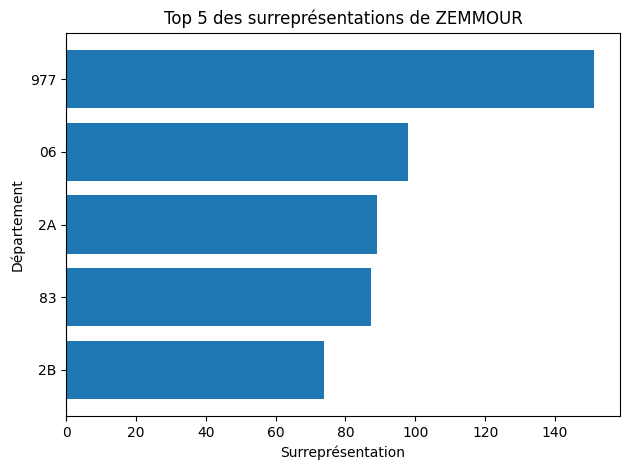

In [20]:
def plot_surrepresentation(nom_candidat, top_n=5):
    data = question5[question5['candidat'].str.contains(nom_candidat)].nlargest(top_n, 'surrepresentation', keep='all')
    # Trier pour que le plus grand soit en haut
    data = data.sort_values('surrepresentation')
   
    plt.figure()
    plt.barh(data['code_departement'], data['surrepresentation'])
    plt.axvline(0, color='steelblue', linewidth=0.8)
    plt.xlabel('Surreprésentation')
    plt.ylabel('Département')
    plt.title(f'Top {top_n} des surreprésentations de {nom_candidat}')
    plt.tight_layout()
    plt.show()

plot_surrepresentation('ZEMMOUR')

NameError: name 'data' is not defined